In [ ]:
#Montar Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Importar las librerias
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import joblib
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt

#Cargar el dataset para entrenar el modelo y el dataset para realizar
#una proyeccion de un trimestre
ruta_2024 = '/content/drive/My Drive/Anexos-CD/Datos/dataset_2024_sin_nombres.csv' #data set completo
ruta_2025 = '/content/drive/My Drive/Anexos-CD/Datos/dataset_2025_sin_nombres.csv' #data set con 2 trimestres

df24 = pd.read_csv(ruta_2024)
df25 = pd.read_csv(ruta_2025)

In [ ]:
# Preprocesamiento de los datos
# Copias de los datasets
df24 = df24.copy()
df25 = df25.copy()

# Convertir trimestre a numérico
map_trimestre = {"1T":1, "2T":2, "3T":3}
df24["trimestre_num"] = df24["trimestre"].map(map_trimestre)
df25["trimestre_num"] = df25["trimestre"].map(map_trimestre)

# Eliminar notas vacías o inválidas
df24 = df24[df24["nota"].between(2,100)] #las notas que son 1 significan aquellos estudiantes que no estaban ese trimestre
df25 = df25[df25["nota"].between(2,100)]

# ONE-HOT ENCODER PARA CATEGÓRICAS
# ================================
# Columnas categóricas
cat_cols = ["curso","materia","nivel","sexo"]

# OneHotEncoder
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

encoder.fit(df24[cat_cols])


# Transformamos
X24_cat = encoder.transform(df24[cat_cols])
X25_cat = encoder.transform(df25[cat_cols])

# Guardar encoder
joblib.dump(encoder, "/content/drive/My Drive/Anexos-CD/Encoders/encoder_rf.joblib")

# Variables numéricas
X24_num = df24[["trimestre_num","matricula"]]
X25_num = df25[["trimestre_num","matricula"]]

# Merge num + categ
X24 = np.hstack([X24_num, X24_cat])
y24 = df24["nota"]

In [ ]:
# Separar Train/Test 2024
# ================================

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X24, y24, df24.index, test_size=0.2, random_state=42
)


In [ ]:
#Buscar los Hiperparametros
# Definir los parámetros que deseas probar
param_grid = {
    "n_estimators": [200, 400, 600],
    "max_depth": [10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["auto", "sqrt"]
}

# Modelo base
rf_model = RandomForestRegressor(random_state=42)

# GridSearch
grid_rf = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    scoring="neg_mean_absolute_error",
    cv=3,
    n_jobs=-1,
    verbose=1
)

# Entrenar
grid_rf.fit(X_train, y_train)

# Mostrar mejores parámetros
print("📌 Mejores parámetros encontrados:")
print(grid_rf.best_params_)

Fitting 3 folds for each of 162 candidates, totalling 486 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


KeyboardInterrupt: 

In [ ]:
# Entrenar modelo
rf = RandomForestRegressor(
    n_estimators=600,
    max_depth=30,
    min_samples_leaf= 1,
    min_samples_split= 10,
    random_state=42
)

rf.fit(X_train, y_train)

pred_test = rf.predict(X_test)


In [ ]:
# EVALUACIÓN

pred_test = rf.predict(X_test)

mae = mean_absolute_error(y_test, pred_test)
r2 = r2_score(y_test, pred_test)
mse = mean_squared_error(y_test, pred_test)
rmse = np.sqrt(mse)

print("MAE:", mae)
print("R2:", r2)
print("RMSE:", rmse)

# GUARDAR MODELO

joblib.dump(rf, "/content/drive/My Drive/Anexos-CD/Modelos/modelo_random_forest_notas.joblib")
print("RandomForest guardado exitosamente.")

MAE: 6.0157770007198375
R2: 0.6654529672767995
RMSE: 7.9674937136837976
RandomForest guardado exitosamente.


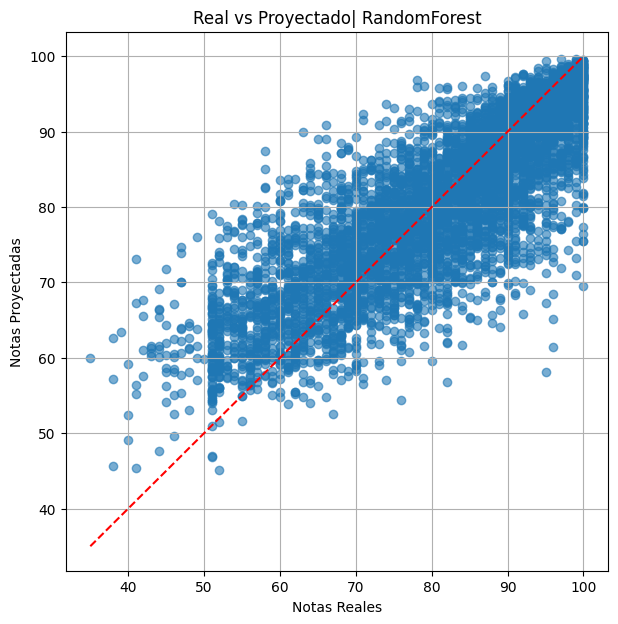

In [ ]:
# 3. Graficar Real vs Predicho
plt.figure(figsize=(7,7))
plt.scatter(y_test, pred_test , alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')

plt.xlabel("Notas Reales")
plt.ylabel("Notas Proyectadas")
plt.title("Real vs Proyectado| RandomForest")
plt.grid(True)
plt.show()

In [ ]:
#Metricas por curso
# Recuperar los datos originales de df24 (curso, materia, nivel, etc.)
df_evalc = df24.loc[idx_test].copy()

df_evalc["nota_real"] = y_test
df_evalc["nota_pred"] = pred_test
metricas = []

for curso, grupo in df_evalc.groupby("curso"):
    real = grupo["nota_real"]
    pred = grupo["nota_pred"]

    mae = mean_absolute_error(real, pred)
    rmse = np.sqrt(mean_squared_error(real, pred))
    r2 = r2_score(real, pred)

    metricas.append({
        "curso": curso,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    })

df_metricas = pd.DataFrame(metricas).sort_values("MAE")
df_metricas

NameError: name 'df24' is not defined